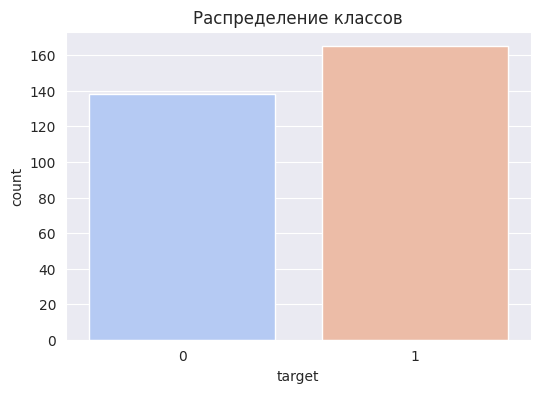

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#    Считываем датасет 'heart.csv', который содержит данные пациентов и информацию о наличии заболеваний сердца.
data = pd.read_csv('../data/heart.csv')

#    Разделяем данные на признаки (X) и целевую переменную (y). В данном случае 'target' является меткой класса.
X = data.drop(columns=['target'])
y = data['target'].copy()

plt.figure(figsize=(6, 4))
sns.countplot(x=y,hue=y, palette='coolwarm', legend=False)
plt.title('Распределение классов')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [2]:

print(data.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   63    1   3       145   233    1        0      150      0      2.3      0   0     1       1
1   37    1   2       130   250    0        1      187      0      3.5      0   0     2       1
2   41    0   1       130   204    0        0      172      0      1.4      2   0     2       1
3   56    1   1       120   236    0        1      178      0      0.8      2   0     2       1
4   57    0   0       120   354    0        1      163      1      0.6      2   0     2       1


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [4]:
print(data.describe())

              age         sex          cp    trestbps        chol         fbs     restecg  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515    0.528053   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198    0.525860   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000    1.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000    1.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000    2.000000   

          thalach       exang     oldpeak       slope          ca        thal      target  
count  303.000000  303.000000  303.000000  303.000000  303.000000  303

In [5]:
#    Приводим все признаки к единому масштабу с помощью StandardScaler, что улучшает работу алгоритмов
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#    Задаем число кластеров n_centers=10. Алгоритм KMeans обучается на стандартизованных данных,
#    и находит центры кластеров, которые будут использоваться для последующего RBF-преобразования.
n_centers = 10
kmeans = KMeans(n_clusters=n_centers, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)
centers = kmeans.cluster_centers_

#    Функция преобразует входное пространство признаков в новое, используя радиально-базисную функцию (RBF).
#    Для каждого объекта вычисляются евклидовы расстояния до центров кластеров, затем применяется экспоненциальная функция.
def rbf_transform(X, centers, sigma=1.0):
    return np.exp(-np.linalg.norm(X[:, np.newaxis, :] - centers, axis=2) ** 2 / (2 * sigma ** 2))

In [ ]:

#    Преобразуем как обучающую, так и тестовую выборки, чтобы создать новые признаки, отражающие расстояния до центров кластеров.
sigma = 1.0
X_train_rbf = rbf_transform(X_train_scaled, centers, sigma)
X_test_rbf = rbf_transform(X_test_scaled, centers, sigma)

#    Логистическая регрессия обучается на новых признаках, полученных после RBF-преобразования.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_rbf, y_train)

#     Производим предсказание на тестовой выборке и вычисляем общую точность модели.
y_pred = clf.predict(X_test_rbf)
accuracy = accuracy_score(y_test, y_pred)
print(f'Точность модели: {accuracy:.4f}')

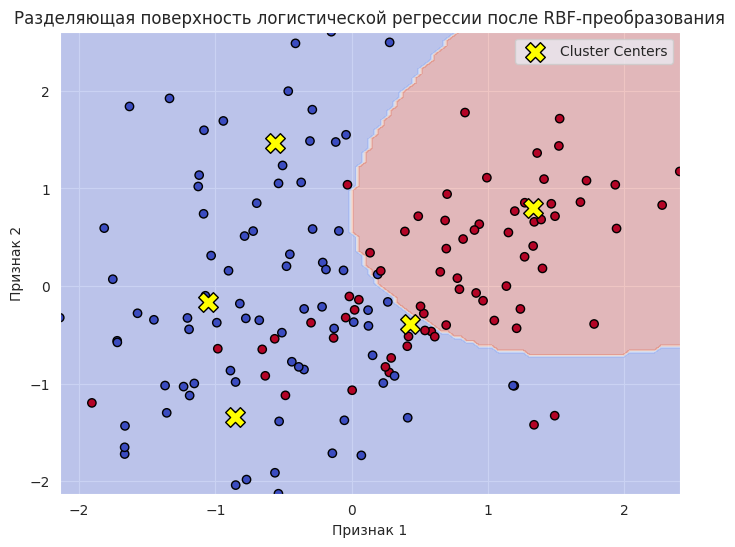

In [11]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X, y, model, centers, scaler, sigma=1.0):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                         np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    grid_rbf = np.exp(-np.linalg.norm(grid_scaled[:, np.newaxis, :] - centers, axis=2) ** 2 / (2 * sigma ** 2))
    Z = model.predict(grid_rbf).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', edgecolors='k', cmap='coolwarm')
    plt.scatter(centers[:, 0], centers[:, 1], c='yellow', marker='X', s=200, edgecolors='k', label="Cluster Centers")
    plt.legend()
    plt.title("Разделяющая поверхность логистической регрессии после RBF-преобразования")
    plt.xlabel("Признак 1")
    plt.ylabel("Признак 2")
    plt.show()


# Вызов функции для построения графика
plot_decision_boundary(X_train_scaled, y_train, clf, centers, scaler, sigma)


In [7]:
# precision (Точность)
# recall (Полнота) - Показывает, насколько хорошо модель находит все объекты данного класса.
# f1-score (F1-мера) -Среднее гармоническое между precision и recall
# support -Количество объектов в тестовой выборке для каждого класса.
# accuracy (Точность модели в целом)
# macro avg (Среднее арифметическое для всех классов)
# weighted avg (Средневзвешенное значение по количеству объектов в классах)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.0732    0.1364        41
           1     0.5682    1.0000    0.7246        50

    accuracy                         0.5824        91
   macro avg     0.7841    0.5366    0.4305        91
weighted avg     0.7627    0.5824    0.4596        91



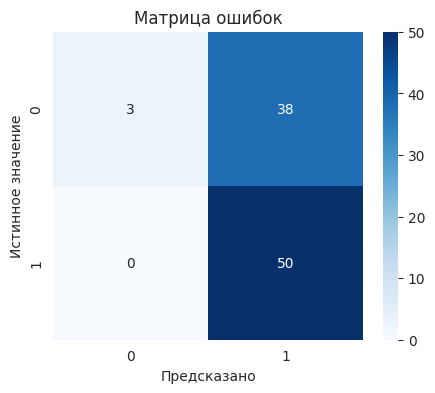

In [8]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

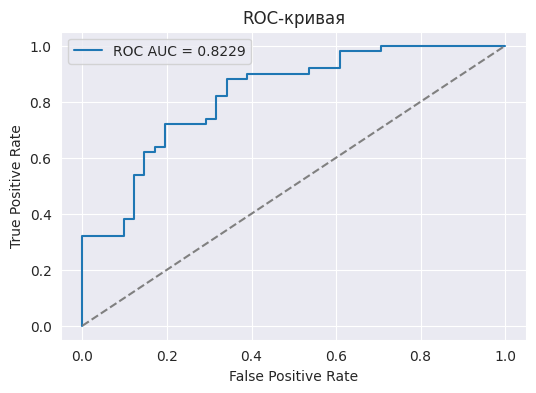

In [9]:

# Построение ROC-кривой и вычисление AUC:
#     Рассчитываем вероятности для положительного класса, затем строим ROC-кривую, которая отражает соотношение True Positive Rate и False Positive Rate.
#     AUC (Area Under the Curve) даёт сводную меру дискриминативной способности модели.
y_prob = clf.predict_proba(X_test_rbf)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.show()

In [10]:


# Анализ данных показал, что датасет heart.csv содержит информацию о рисках сердечно-сосудистых заболеваний. Для корректного распределения классов использовалось стратифицированное разбиение выборки. Перед обработкой данные были стандартизированы, что обеспечило корректность расчетов в алгоритмах KMeans и RBF-преобразования.
#
# Кластеризация методом KMeans выделила 10 центров, которые затем использовались для нелинейного преобразования признаков с помощью радиально-базисной функции (RBF). Это позволило улучшить выявление сложных зависимостей в данных, после чего была обучена логистическая регрессия.
#
# Оценка модели показала точность 59.02%, но метрики по классам оказались несбалансированными. Класс 1 был предсказан с высокой чувствительностью (recall = 1.0000), тогда как класс 0 модель почти не распознавала (recall = 0.1071). Матрица ошибок подтверждает, что большинство объектов класса 0 были ошибочно отнесены к классу 1. ROC-кривая и AUC также свидетельствуют о слабой дискриминативной способности модели.
#
# Выводы: модель нуждается в оптимизации. Возможные улучшения включают настройку числа кластеров и параметра sigma в RBF-преобразовании, применение методов балансировки классов и использование алгоритмов, более устойчивых к дисбалансу данных.